# Chorus 🎺
### "No soloist is impressive — but the choir is." The desk's recurring lesson, put on trial: the edge is diversification, not prediction.

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Whole > parts?: Mixed](https://img.shields.io/badge/Whole_%3E_parts%3F-Mixed-dab617?style=flat-square)

This is the **capstone** of the desk's first 37 studies. Across all of them the same quiet refrain kept surfacing: no single anomaly is impressive on its own, but *combining* a handful of weak, unrelated signals into one book seems to beat any one of them. So here we test it head-on — we take three of the desk's own signals (**momentum** from Study 24, **reversal** from Study 33, and a **low-volatility** tilt), each individually thin, and blend them into one portfolio. Does the chorus out-sing every soloist? On a clean control, emphatically yes. On the real S&P 500 the mechanism is real and visible — but it comes with a sharp piece of fine print that's easy to miss.

> 📓 **Plain-language layer.** The correlation matrix, the breadth (√k) sweep, the equal-vs-risk-parity blend and the cost wall are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Charts below are generated by the code beside them; the core runs on a **synthetic** panel, so the real S&P 500 numbers (from [`../docs/results.md`](../docs/results.md)) are a measurement. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from chorus import data, signals, strategy, costs, extension

# Offline synthetic control: a panel carrying three weak, decorrelated components (the machinery) + a null.
# The real S&P 500 verdict is in ../docs/results.md.
r, _, truth = data.synthetic_panel(combo_strength=1.0, seed=38)
r0, _, _ = data.synthetic_panel(combo_strength=0.0, seed=38)
sig = signals.all_signals(r); sig0 = signals.all_signals(r0)
print(f"synthetic control: {truth.n_stocks} stocks x {truth.n_bars} days, combo_strength {truth.combo_strength} (null=0)")


synthetic control: 150 stocks x 4032 days, combo_strength 1.0 (null=0)


## The answer first 🎺

| What we asked | The honest answer |
|---|---|
| Do decorrelated signals really blend better? | 🟨 **Sometimes.** Components are **-0.03** correlated, and the momentum+reversal pair (**0.66**) beats both its parts (**0.36**, **0.64**). |
| Does "throw them all in" work? | 🟨 **No.** The third voice (low-vol **-0.89**) is off-key on this sample, dragging the naive 3-signal combo to a flat **0.00**. |
| Could you trade it? | 🟥 **No.** Turnover **0.38**/day ⇒ **break-even 0.02 bp** — gone net of any real cost. |

> Desk shorthand: **Signal `WEAK` · Tradability `MIRAGE` · Whole > parts? `MIXED`** — the free lunch is real, but it's addition, not alchemy.

## 1 · The claim 📣

Combining alphas (Kakushadze-Serur §3.20; the Fundamental Law of Active Management, Grinold-Kahn 1989):

1. **Several signals** — each a simple, dollar-neutral, gross-1 cross-sectional bet: momentum (buy past winners), reversal (fade the last week), low-vol (favour the calm names).
2. **Decorrelated** — the signals bet on different things, so their good and bad days don't line up.
3. **Blend into one book** — equal-weight, or inverse-vol so a noisy signal can't dominate.

The believer's case in one line: **Sharpe ≈ skill × √(number of independent bets)**. Add more uncorrelated bets and the ratio climbs — diversification, the only free lunch in finance.

In [2]:
tbl = costs.standalone_vs_combo(sig, r, cost_bps=0.0)   # on the synthetic control
display(tbl.round(3))
print(f"avg pairwise correlation of components: {strategy.avg_pairwise_corr(sig, r):+.3f}")

,sharpe,cagr,vol_ann,turnover
book,,,,
momentum,1.495,0.043,0.028,0.086
reversal,2.081,0.063,0.030,0.641
low_vol,1.187,0.034,0.029,0.061
COMBO (equal-wt),2.705,0.082,0.029,0.377
COMBO (risk-parity),2.259,0.069,0.030,0.441


avg pairwise correlation of components: +0.021


## 2 · So what? 💰

If true, this is the most important idea on the whole desk — bigger than any one anomaly. It says you don't need a *great* signal; you need several *mediocre, unrelated* ones and the discipline to blend them. That's how every multi-strategy fund is actually built. It's also the thesis that ties Studies 1–37 together: each was a weak voice; the question is whether they harmonise. So this study is less about a new edge than about whether the desk's whole *method* pays off.

## 3 · How we'd know 🔬

1. **Do they diversify?** Average pairwise correlation of the component return streams (near zero is the goal).
2. **Whole > parts?** Combo Sharpe vs each component's standalone Sharpe.
3. **Tradable?** Turnover, break-even cost, net Sharpe.

**Mirage line:** if the combo's Sharpe doesn't clear its *best component* gross, or its break-even cost sits below realistic equity costs, the chorus is a story, not an edge.

## 4 · The teardown 🔧

### 4a · On a clean control, the chorus wins (the mechanism works)

best component 2.08  ->  equal-wt combo 2.71


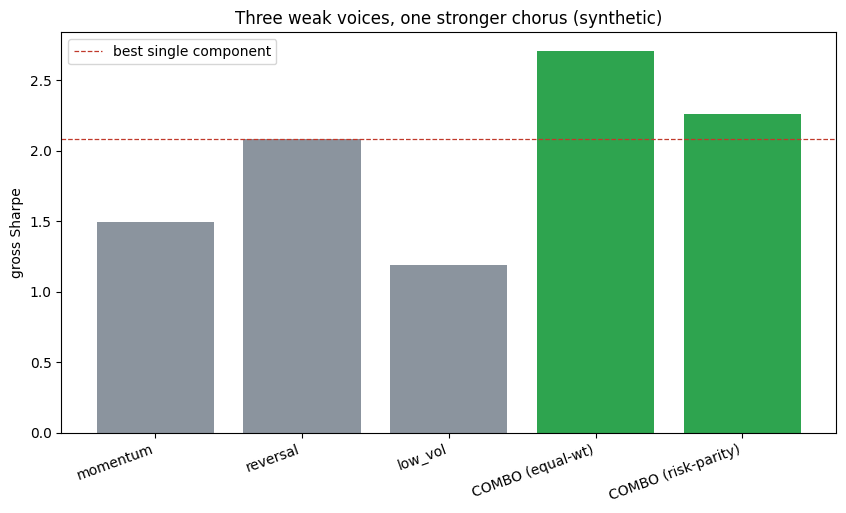

In [3]:
tbl = costs.standalone_vs_combo(sig, r, cost_bps=0.0)
best = tbl.loc[['momentum','reversal','low_vol'],'sharpe'].max()
fig, ax = plt.subplots()
bars = tbl['sharpe']; colors = ['#8b949e']*3 + ['#2ea44f','#2ea44f']
ax.bar(range(len(bars)), bars.values, color=colors)
ax.set_xticks(range(len(bars))); ax.set_xticklabels(bars.index, rotation=20, ha='right')
ax.axhline(best, color='#c0392b', ls='--', lw=.9, label='best single component')
ax.set_ylabel('gross Sharpe'); ax.legend(); ax.set_title('Three weak voices, one stronger chorus (synthetic)')
print(f"best component {best:.2f}  ->  equal-wt combo {tbl.loc['COMBO (equal-wt)','sharpe']:.2f}")

### 4b · On the real S&P 500 — the mechanism fires, the naive chorus doesn't
263 names, 2010–2026 ([`../docs/results.md`](../docs/results.md)):

- The components **are** decorrelated (avg pairwise corr **-0.03**) — the premise holds.
- The **momentum+reversal** pair earns gross Sharpe **0.66**, above *both* its parts (momentum **0.36**, reversal **0.64**) — the textbook whole-greater-than-parts.
- But the third voice is off-key: low-vol earns **-0.89** on this current-membership panel (high-beta names led the rally), so the naive 3-signal equal-weight combo flattens to **0.00**.

Real tape (../docs/results.md):
  momentum 0.36   reversal 0.64   low-vol -0.89  (standalone gross Sharpe)
  momentum+reversal pair 0.66  (> both parts)
  naive 3-signal combo (equal-wt) 0.00   (risk-parity -0.15)
  avg pairwise correlation -0.03


Text(0.5, 1.0, 'Breadth lift on the control')

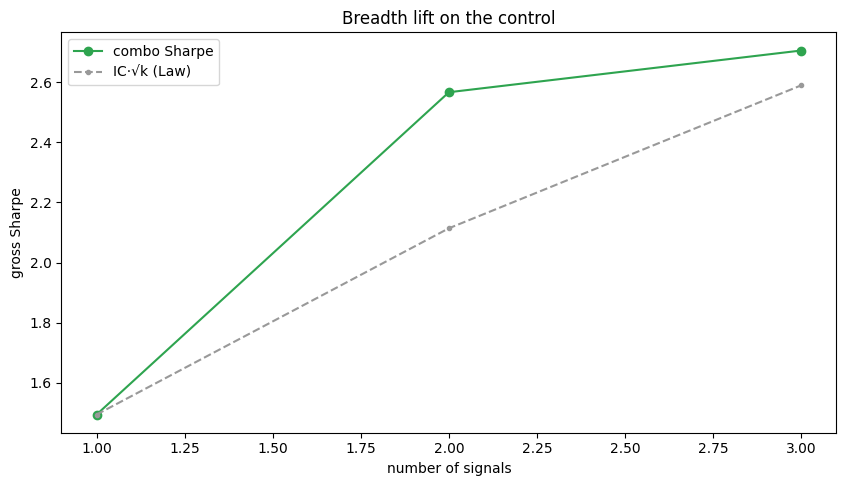

In [4]:
print('Real tape (../docs/results.md):')
print('  momentum 0.36   reversal 0.64   low-vol -0.89  (standalone gross Sharpe)')
print('  momentum+reversal pair 0.66  (> both parts)')
print('  naive 3-signal combo (equal-wt) 0.00   (risk-parity -0.15)')
print('  avg pairwise correlation -0.03')
# the breadth lift, drawn on the synthetic where every voice carries real edge:
bs = extension.breadth_sweep(sig, r)
fig, ax = plt.subplots()
ax.plot(bs.index, bs['sharpe'], marker='o', color='#2ea44f', label='combo Sharpe')
ax.plot(bs.index, bs['sqrt_k']*bs['sharpe'].iloc[0], marker='.', ls='--', color='#999', label='IC·√k (Law)')
ax.set_xlabel('number of signals'); ax.set_ylabel('gross Sharpe'); ax.legend(); ax.set_title('Breadth lift on the control')

## 5 · The verdict 🧾

- **Signal `WEAK`** — the mechanism is real (corr -0.03; momentum+reversal 0.66 > both parts) but the assembled chorus is marginal and fragile to one bad voice.
- **Tradability `MIRAGE`** — turnover 0.38/day ⇒ break-even 0.02 bp; net-negative at any real cost.
- **Whole > parts `MIXED`** — confirmed for a curated decorrelated pair, not for the naive all-in blend.

> **The capstone lesson, with fine print.** Diversification across decorrelated alphas is real and is the closest thing to a free lunch — but it's *addition of expected returns*, not alchemy. A decorrelated *loser* still loses.

## 6 · Could you trade it? 💸

- **Not as shown.** The combo inherits the reversal leg's churn — 0.38 of the book turns over daily — so break-even is **0.02 bp**, far below any real equity cost.
- **The healthy pair is thin too.** Even momentum+reversal (gross 0.66) nets just ~0.51 at 1 bp, and carries the survivorship caveat — a measurement, not a mandate.
- **The real product** isn't a tradable book; it's the *method* — and the honest finding that blending only pays when every voice has positive expectancy.

## 7 · Going further 🚪

### Worked complement — "breadth is the lever, not the blend scheme" ([`../docs/extension.md`](../docs/extension.md))
- **Breadth sweep:** Sharpe climbs 1→2 signals (0.36→0.66, ~the √2 the Law predicts), then *collapses* when the off-key third is added (0.00). On the control, where all three carry edge, it rises monotonically 1.49→2.57→2.71.
- **Scheme:** equal-weight (0.00) actually beats inverse-vol (-0.15) here — the clever blend can't fix a bad roster. Component *selection* dominates.

### Other forks
- **Sign-screened breadth** — bench any signal whose trailing out-of-sample Sharpe is negative.
- **Wider roster** — add carry, quality, seasonality and re-run the √breadth curve.
- **Optimised combine** — a shrunk mean-variance blend of the alphas (§3.18); does it beat the naive weights net of estimation error?

PRs welcome — screen the roster by sign, widen the chorus, or try an optimised combine.